In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape :", df.shape)

df.info()

Shape : (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

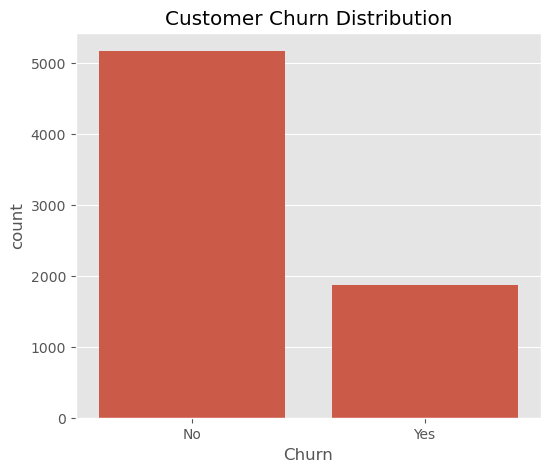

In [7]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")

plt.show()

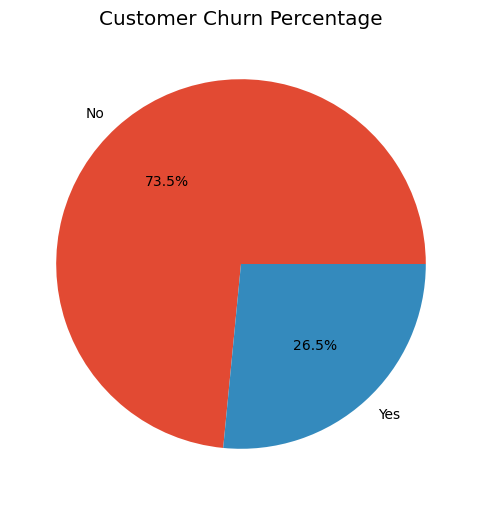

In [8]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Customer Churn Percentage")

plt.show()

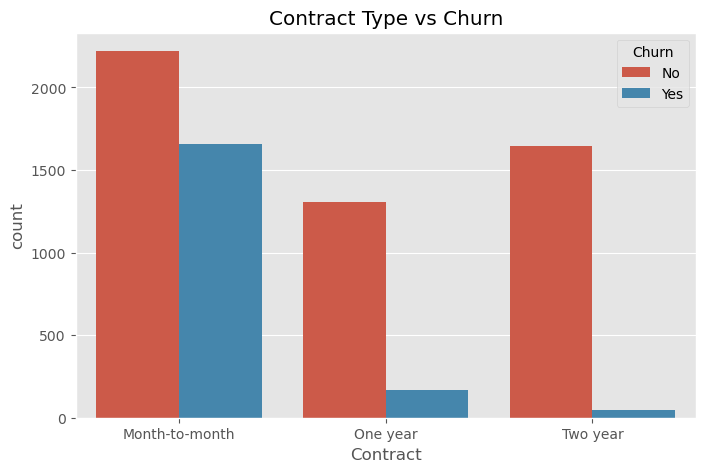

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")

plt.show()

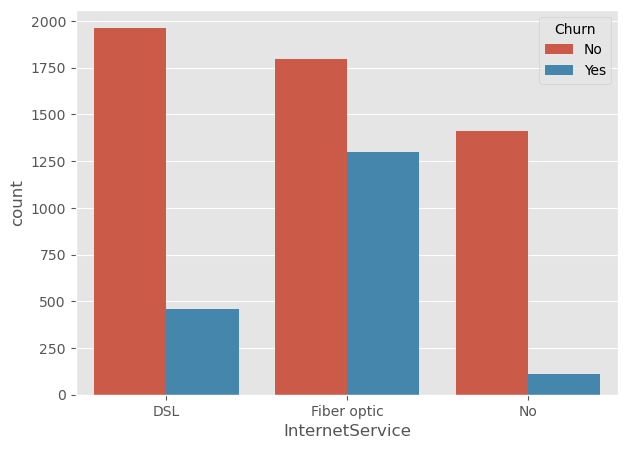

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.show()

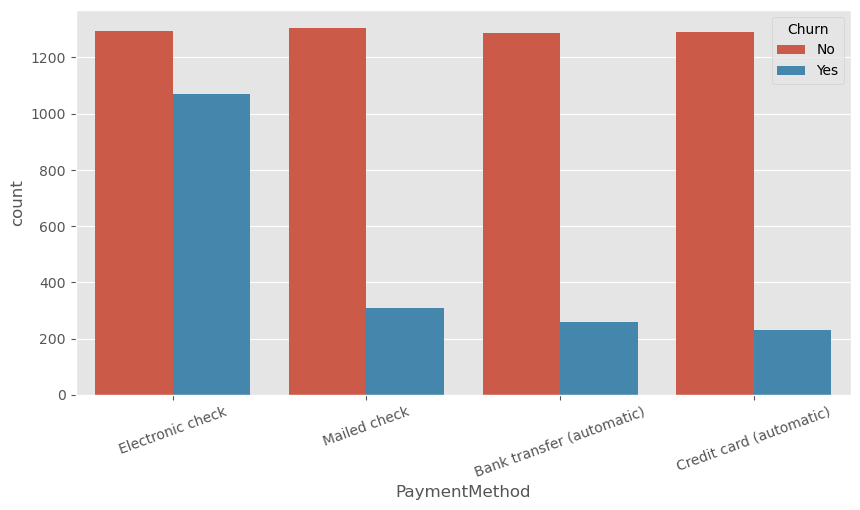

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=20)

plt.show()

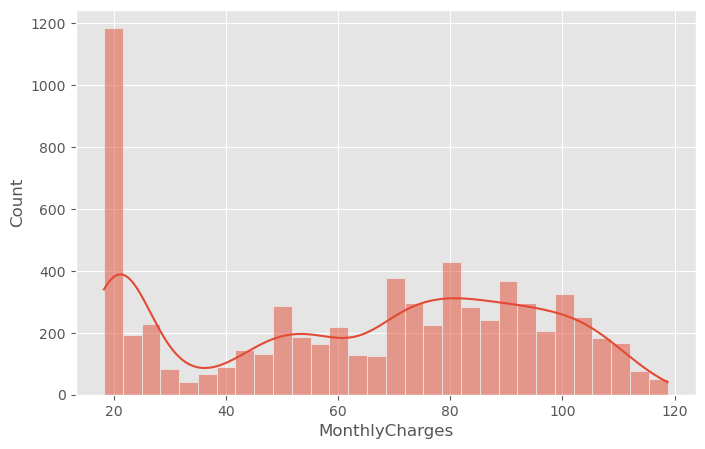

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.show()

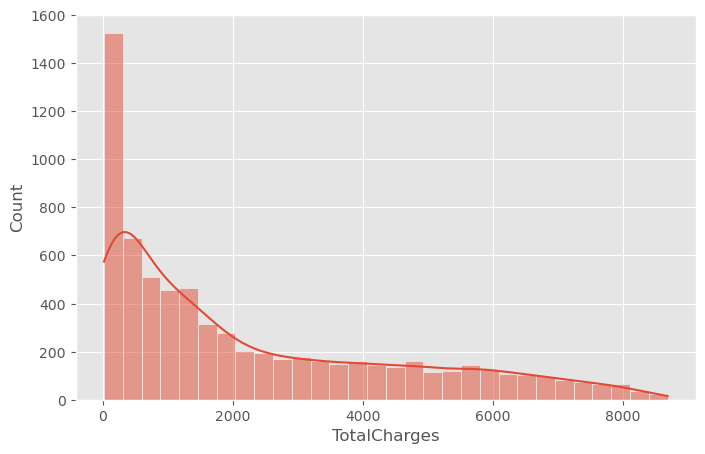

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["TotalCharges"],
    bins=30,
    kde=True
)

plt.show()

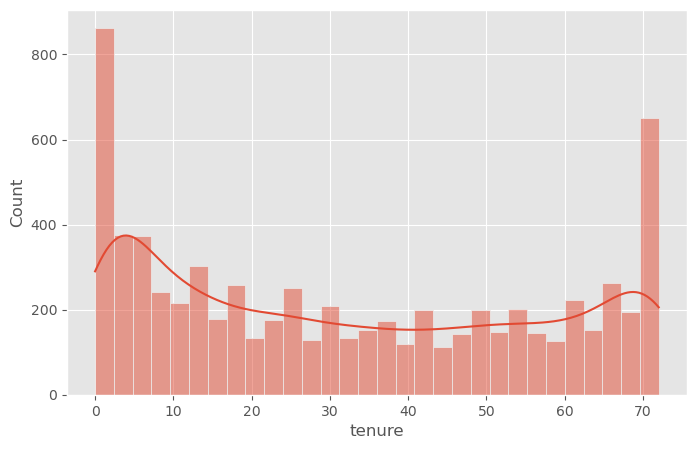

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True
)

plt.show()

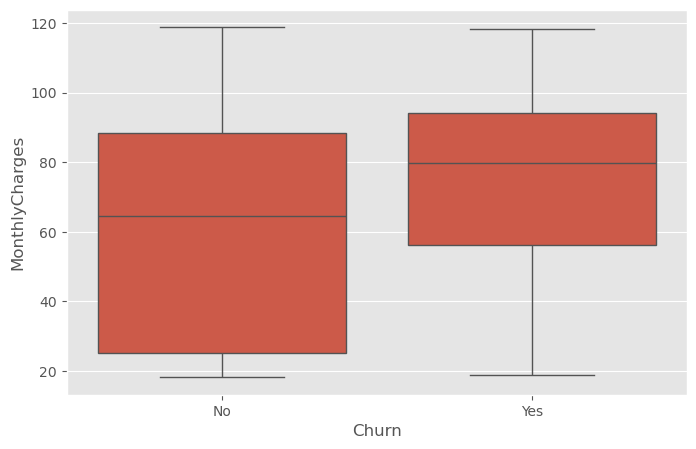

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.show()

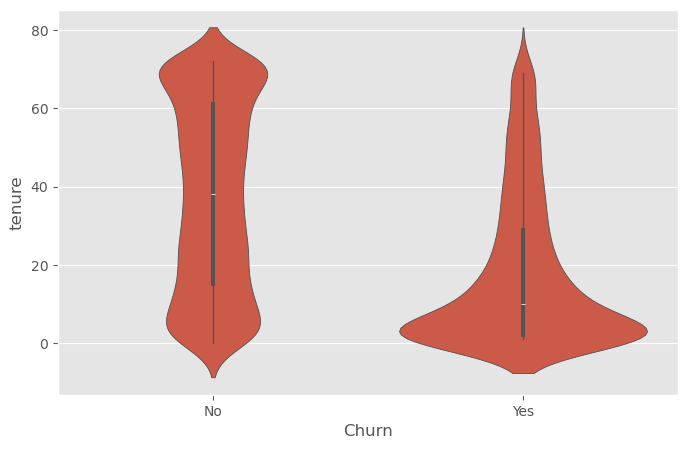

In [16]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.show()

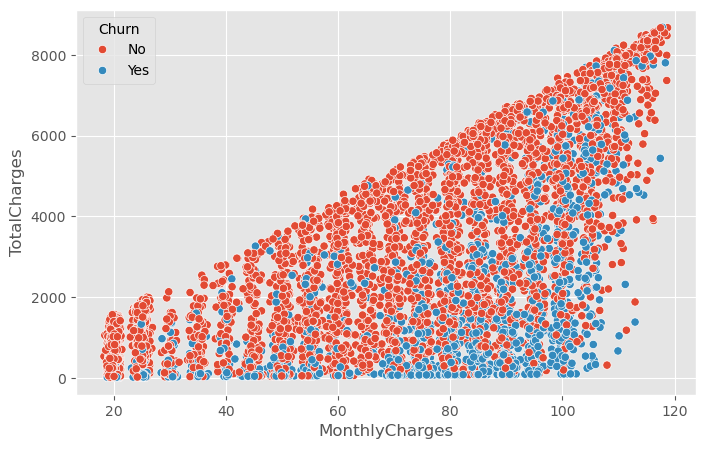

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="Churn"
)

plt.show()

In [19]:
df2 = df.copy()

binary = {
    "Yes":1,
    "No":0,
    "Male":1,
    "Female":0
}

for col in df2.columns:
    if df2[col].dtype=="object":
        df2[col]=df2[col].replace(binary)

corr = df2.corr(numeric_only=True)

corr

C:\Users\Manav\AppData\Local\Temp\ipykernel_27716\3689755309.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col]=df2[col].replace(binary)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.011754,-0.014569,-0.000002,-0.008612
SeniorCitizen,-0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.102652,0.150889
Partner,-0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,0.318364,-0.150448
Dependents,0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,0.063593,-0.164221
tenure,0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,0.825464,-0.352229
PhoneService,-0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,0.016505,0.247398,0.113013,0.011942
PaperlessBilling,-0.011754,0.156530,-0.014877,-0.111377,0.006152,0.016505,1.000000,0.352150,0.158055,0.191825
MonthlyCharges,-0.014569,0.220173,0.096848,-0.113890,0.247900,0.247398,0.352150,1.000000,0.650864,0.193356
TotalCharges,-0.000002,0.102652,0.318364,0.063593,0.825464,0.113013,0.158055,0.650864,1.000000,-0.199037
Churn,-0.008612,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,-0.199037,1.000000


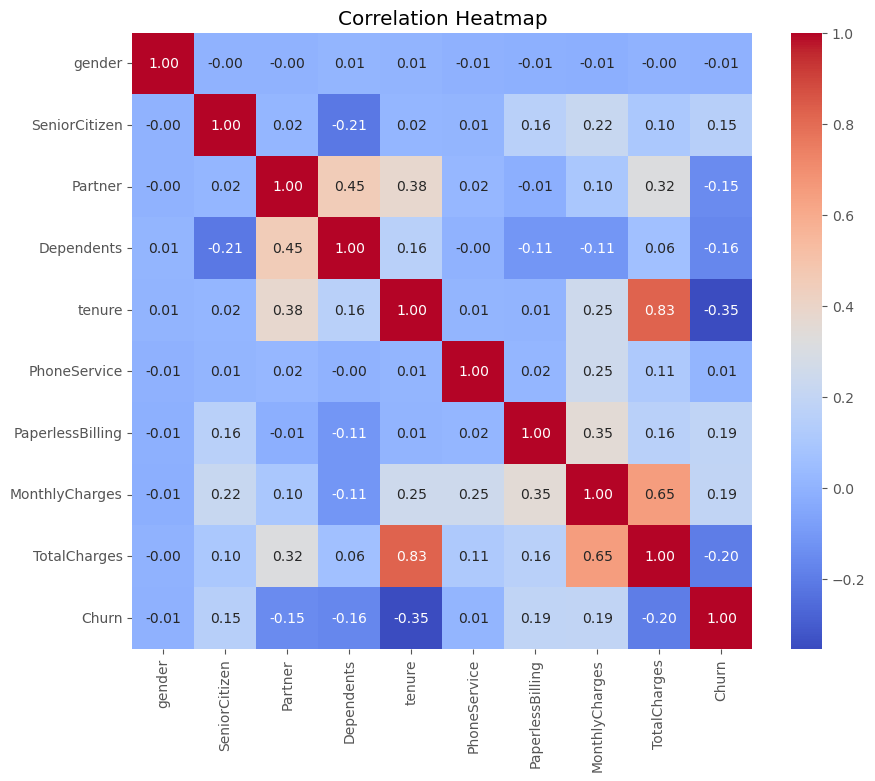

In [20]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

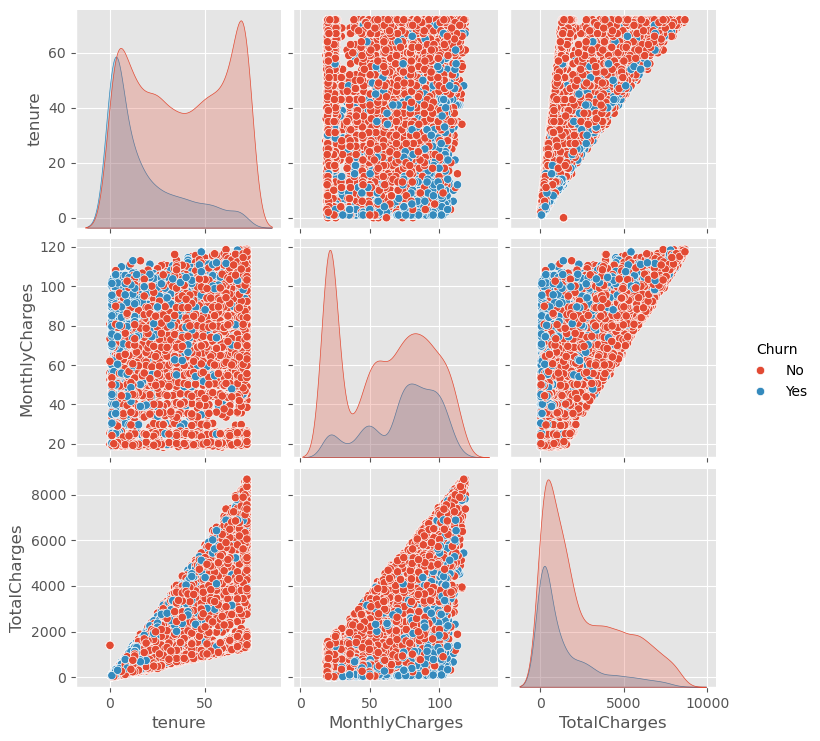

In [23]:
sns.pairplot(
    df[
        [
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "Churn"
        ]
    ],
    hue="Churn"
)

plt.show()

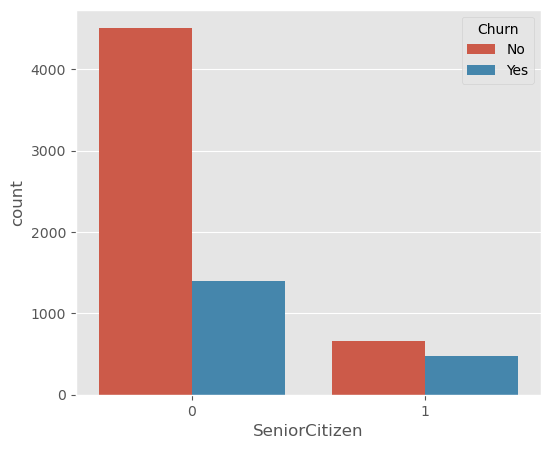

In [22]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.show()

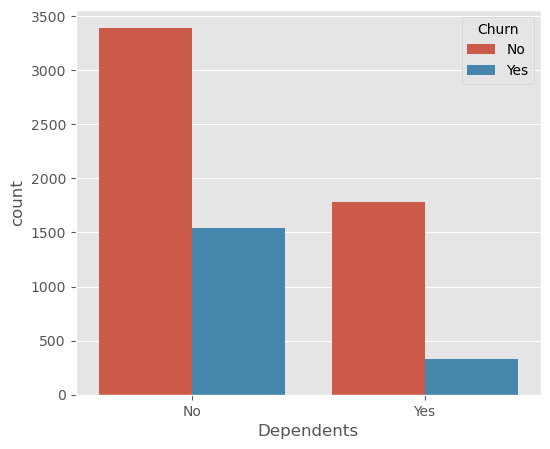

In [26]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn"
)
plt.show()

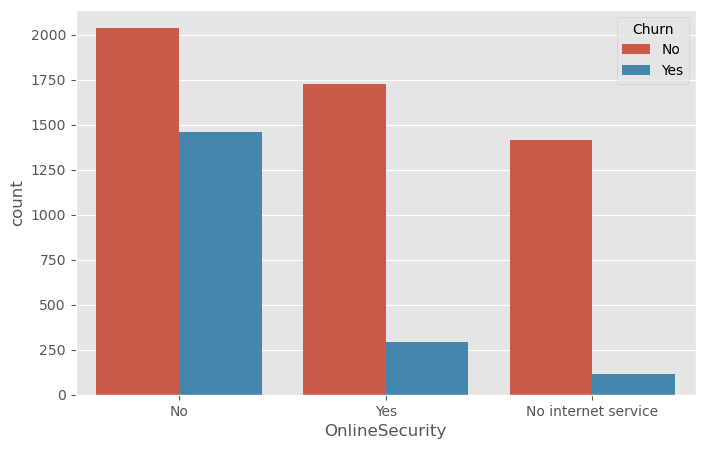

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn"
)

plt.show()

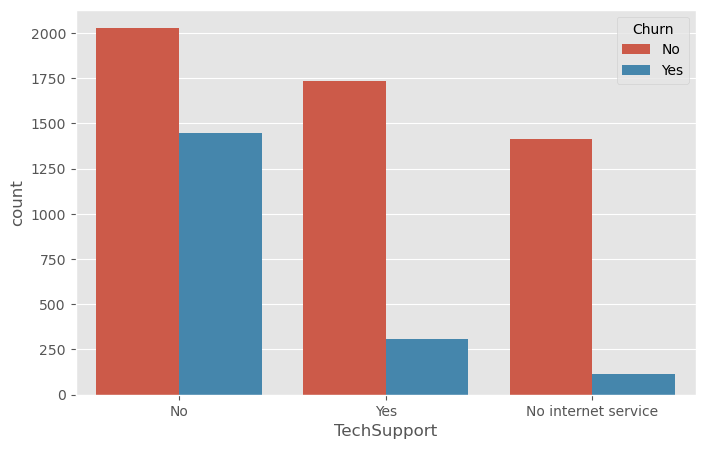

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.show()

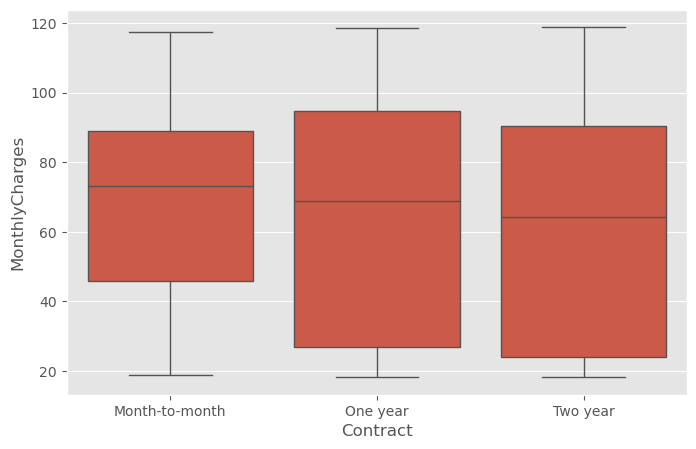

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Contract",
    y="MonthlyCharges"
)

plt.show()

In [29]:
avg = df.groupby("Contract")["MonthlyCharges"].mean()

print(avg)

Contract
Month-to-month    66.398490
One year          65.048608
Two year          60.770413
Name: MonthlyCharges, dtype: float64


In [30]:
contract_churn = (
    df.groupby("Contract")["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

print(contract_churn)

         Contract Churn  Percentage
0  Month-to-month    No   57.290323
1  Month-to-month   Yes   42.709677
2        One year    No   88.730482
3        One year   Yes   11.269518
4        Two year    No   97.168142
5        Two year   Yes    2.831858


In [31]:
print("""
EDA Insights

1. Month-to-month customers churn the most.

2. Customers with higher monthly charges have higher churn.

3. Longer-tenure customers are more loyal.

4. Fiber optic customers have relatively higher churn.

5. Electronic check users churn more frequently.

6. Customers without Online Security tend to churn more.

7. Customers without Tech Support are more likely to leave.

8. One-year and two-year contracts have the lowest churn.
""")


EDA Insights

1. Month-to-month customers churn the most.

2. Customers with higher monthly charges have higher churn.

3. Longer-tenure customers are more loyal.

4. Fiber optic customers have relatively higher churn.

5. Electronic check users churn more frequently.

6. Customers without Online Security tend to churn more.

7. Customers without Tech Support are more likely to leave.

8. One-year and two-year contracts have the lowest churn.



In [32]:
print("""
Conclusion

EDA helped identify the major factors affecting customer churn.

These findings will guide feature selection and predictive modeling in the next phase of the project.
""")


Conclusion

EDA helped identify the major factors affecting customer churn.

These findings will guide feature selection and predictive modeling in the next phase of the project.

